# ch220 — Approximation

Approximation is the practical art of trading exactness for efficiency. No real system operates with infinite precision. Every floating-point number is an approximation *(ch018 — Precision and Floating Point Errors)*. Every numerical derivative is an approximation *(ch207)*. Taylor series *(ch219)* are approximations.

The question is never "is this exact?" — it is "is this accurate enough for the purpose?"

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

# ── Approximating sin(x) to machine precision ──────────────────────────────
# How many Taylor terms does it take?

def sin_taylor(x, n_terms):
    result = 0.0
    for k in range(n_terms):
        result += ((-1)**k * x**(2*k+1)) / factorial(2*k+1)
    return result

x_test = np.pi / 3  # 60 degrees
exact = np.sin(x_test)

errors = [abs(sin_taylor(x_test, n) - exact) for n in range(1, 12)]
print(f"sin(pi/3) exact: {exact:.15f}")
print()
print(f"{'Terms':>6} | {'Approximation':>18} | {'Error':>12}")
print("-" * 42)
for n in range(1, 12):
    approx = sin_taylor(x_test, n)
    err = abs(approx - exact)
    print(f"{n:>6} | {approx:>18.15f} | {err:>12.2e}")


sin(pi/3) exact: 0.866025403784439

 Terms |      Approximation |        Error
------------------------------------------
     1 |  1.047197551196598 |     1.81e-01
     2 |  0.855800781565117 |     1.02e-02
     3 |  0.866295283786835 |     2.70e-04
     4 |  0.866021271656373 |     4.13e-06
     5 |  0.866025445099781 |     4.13e-08
     6 |  0.866025403493483 |     2.91e-10
     7 |  0.866025403785960 |     1.52e-12
     8 |  0.866025403784432 |     6.22e-15
     9 |  0.866025403784438 |     1.11e-16
    10 |  0.866025403784438 |     1.11e-16
    11 |  0.866025403784438 |     1.11e-16


## Approximation Error Taxonomy

Different error types dominate at different scales:

| Error type | Source | Control |
|---|---|---|
| Truncation | Cutting off an infinite series | More terms |
| Round-off | Finite floating-point precision | Unavoidable at 64-bit |
| Discretisation | Grid-based approximation | Finer grid |
| Modelling | Wrong model for the problem | Better model |

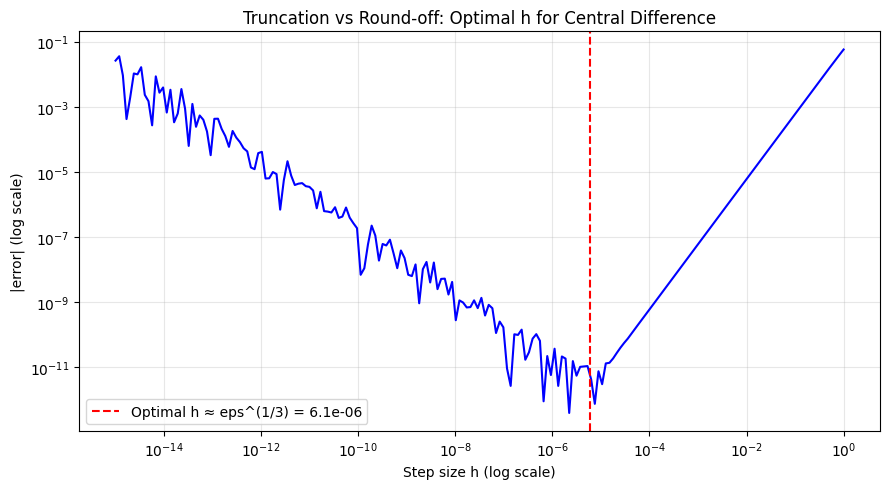

Machine epsilon: 2.22e-16
Optimal h: 6.06e-06


In [2]:
# Demonstrate truncation vs round-off error tradeoff in numerical diff
# Central difference: (f(x+h) - f(x-h)) / 2h
# Truncation error: O(h^2)  -- smaller h = less truncation
# Round-off error: O(eps/h) -- smaller h = more round-off
# Optimal h ≈ eps^(1/3) for central difference

x0 = 1.2
exact_deriv = np.cos(x0)  # d/dx sin(x) = cos(x)

h_vals = np.logspace(-15, 0, 200)
errors = []
for h in h_vals:
    approx = (np.sin(x0 + h) - np.sin(x0 - h)) / (2*h)
    errors.append(abs(approx - exact_deriv))

plt.figure(figsize=(9, 5))
plt.loglog(h_vals, errors, 'b', lw=1.5)
plt.xlabel('Step size h (log scale)'); plt.ylabel('|error| (log scale)')
plt.title('Truncation vs Round-off: Optimal h for Central Difference')
plt.grid(True, which='both', alpha=0.3)
opt_h = np.finfo(float).eps ** (1/3)
plt.axvline(opt_h, color='red', ls='--', label=f'Optimal h ≈ eps^(1/3) = {opt_h:.1e}')
plt.legend()
plt.tight_layout(); plt.savefig('ch220_tradeoff.png', dpi=100); plt.show()
print(f"Machine epsilon: {np.finfo(float).eps:.2e}")
print(f"Optimal h: {opt_h:.2e}")


## Polynomial Approximation via Least Squares

When you don't know the function's derivatives, you can still approximate it using data points. Fit a polynomial of degree N through sampled data *(forward reference: ch222 — Area Under Curve, ch271 — Regression)*.

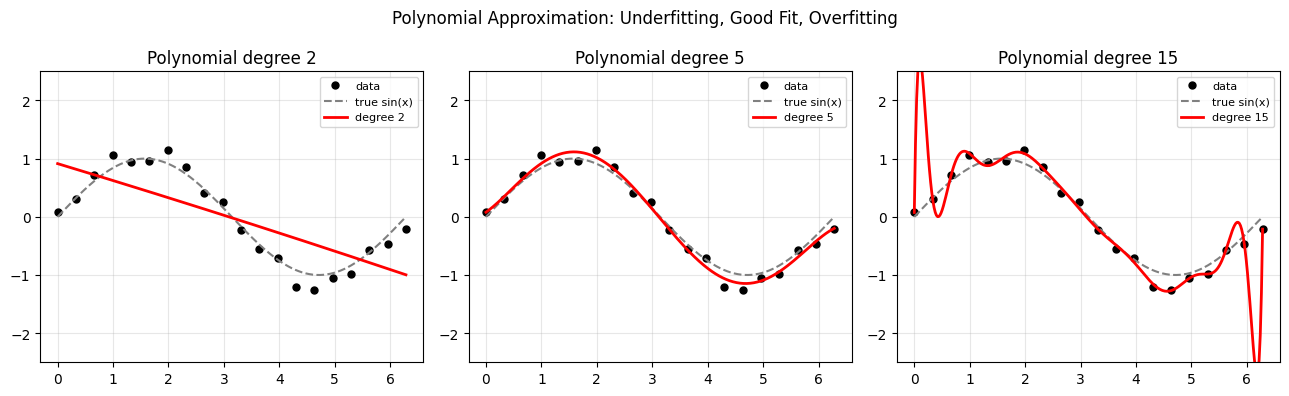

In [3]:
# Approximate a noisy signal with polynomials of different degrees
np.random.seed(42)
x_data = np.linspace(0, 2*np.pi, 20)
y_data = np.sin(x_data) + np.random.normal(0, 0.15, 20)

x_plot = np.linspace(0, 2*np.pi, 300)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, deg in zip(axes, [2, 5, 15]):
    coeffs = np.polyfit(x_data, y_data, deg)
    y_fit = np.polyval(coeffs, x_plot)
    ax.plot(x_data, y_data, 'ko', ms=5, label='data')
    ax.plot(x_plot, np.sin(x_plot), 'gray', ls='--', label='true sin(x)')
    ax.plot(x_plot, y_fit, 'r', lw=2, label=f'degree {deg}')
    ax.set_ylim(-2.5, 2.5); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.set_title(f'Polynomial degree {deg}')
plt.suptitle('Polynomial Approximation: Underfitting, Good Fit, Overfitting')
plt.tight_layout(); plt.savefig('ch220_poly_approx.png', dpi=100); plt.show()


## Summary

| Principle | Lesson |
|---|---|
| All numerical computation involves approximation | Precision is a resource to manage |
| Optimal h for numerical derivatives | eps^(1/3) for central difference |
| Polynomial degree | Too low = underfitting, too high = overfitting |
| Error analysis | Always quantify, never ignore |

**Forward reference:** ch221 — Integration Intuition applies approximation thinking directly to computing areas, where small strips approximate the exact integral.